# PiyoLog Data Analysis

In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [2]:
# Load data
df = pl.read_csv("../processed_data/piyolog.csv")
df.head()

date,datetime,days_from_birth,time,event,milk_amount,sleep_minutes
str,str,i64,str,str,i64,i64
"""2023-01-01""","""2023-01-01 22:00""",0,"""22:00""","""breastfeeding""",null,null
"""2023-01-02""","""2023-01-02 05:00""",1,"""05:00""","""formula""",5,null
"""2023-01-02""","""2023-01-02 08:00""",1,"""08:00""","""breastfeeding""",null,null
"""2023-01-02""","""2023-01-02 08:00""",1,"""08:00""","""formula""",5,null
"""2023-01-02""","""2023-01-02 10:00""",1,"""10:00""","""pee""",null,null


In [3]:
df.describe()

statistic,date,datetime,days_from_birth,time,event,milk_amount,sleep_minutes
str,str,str,f64,str,str,f64,f64
"""count""","""13600""","""13600""",13600.0,"""13600""","""13600""",2312.0,3402.0
"""null_count""","""0""","""0""",0.0,"""0""","""0""",11288.0,10198.0
"""mean""",null,null,243.3225,null,null,122.084775,176.872428
"""std""",null,null,183.621959,null,null,42.122667,173.798205
"""min""","""2023-01-01""","""2023-01-01 22:00""",0.0,"""00:00""","""bath""",5.0,0.0
"""25%""",null,null,97.0,null,null,100.0,60.0
"""50%""",null,null,211.0,null,null,130.0,110.0
"""75%""",null,null,337.0,null,null,150.0,215.0
"""max""","""2025-03-22""","""2025-03-22 15:20""",811.0,"""23:55""","""weight""",210.0,760.0


In [4]:
event_counts = df.group_by("event").len().sort("len", descending=True)
event_counts

event,len
str,u32
"""wake_up""",3404
"""sleep""",3402
"""pee""",3223
"""formula""",2312
"""poop""",508
…,…
"""drink""",30
"""height""",16
"""hospital""",16


## Daily Milk Intake

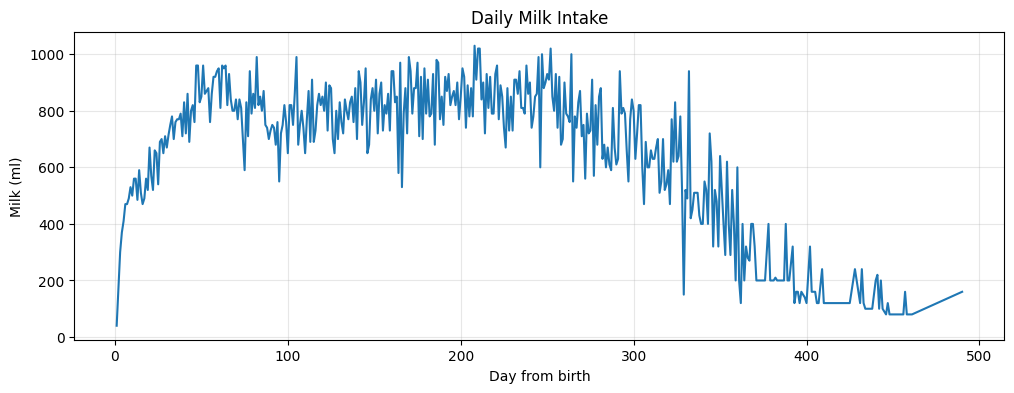

In [5]:
# Daily milk intake
daily_milk = (
    df.filter(pl.col("event") == "formula")
    .group_by("days_from_birth")
    .agg(pl.col("milk_amount").sum().alias("total_ml"))
    .sort("days_from_birth")
)

plt.figure(figsize=(12, 4))
plt.plot(daily_milk["days_from_birth"], daily_milk["total_ml"])
plt.xlabel("Day from birth")
plt.ylabel("Milk (ml)")
plt.title("Daily Milk Intake")
plt.grid(True, alpha=0.3)
plt.show()

## Sleep Duration

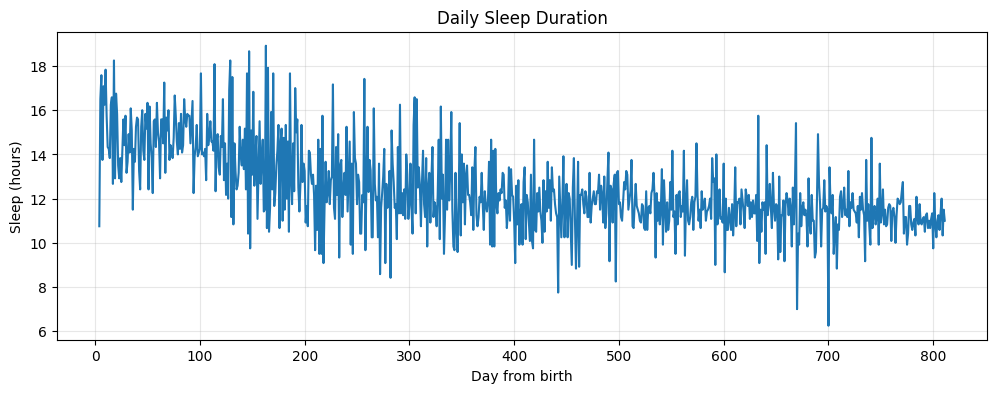

In [6]:
# Daily total sleep
daily_sleep = (
    df.filter(pl.col("event") == "wake_up")
    .group_by("days_from_birth")
    .agg((pl.col("sleep_minutes").sum() / 60).alias("total_hours"))
    .sort("days_from_birth")
)

plt.figure(figsize=(12, 4))
plt.plot(daily_sleep["days_from_birth"], daily_sleep["total_hours"])
plt.xlabel("Day from birth")
plt.ylabel("Sleep (hours)")
plt.title("Daily Sleep Duration")
plt.grid(True, alpha=0.3)
plt.show()

## Monthly Averages

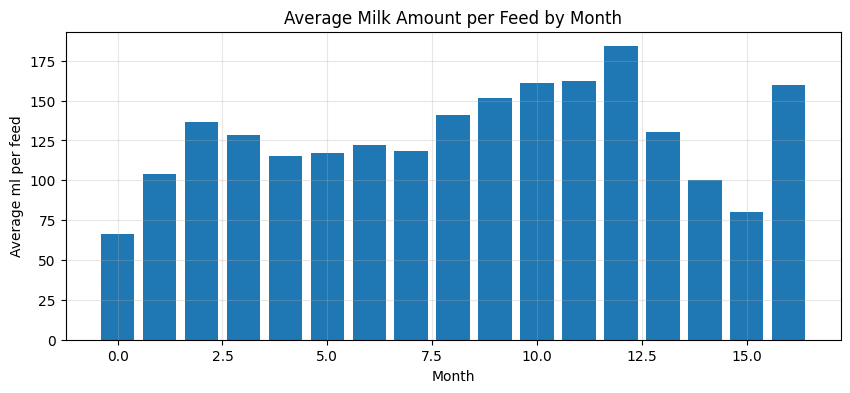

In [7]:
# Monthly milk average (derive month from days_from_birth)
monthly_milk = (
    df.filter(pl.col("event") == "formula")
    .with_columns((pl.col("days_from_birth") / 30.44).cast(pl.Int32).alias("month"))
    .group_by("month")
    .agg(pl.col("milk_amount").mean().alias("avg_ml_per_feed"))
    .sort("month")
)

plt.figure(figsize=(10, 4))
plt.bar(monthly_milk["month"], monthly_milk["avg_ml_per_feed"])
plt.xlabel("Month")
plt.ylabel("Average ml per feed")
plt.title("Average Milk Amount per Feed by Month")
plt.grid(True, alpha=0.3)
plt.show()

## Event Frequency by Hour

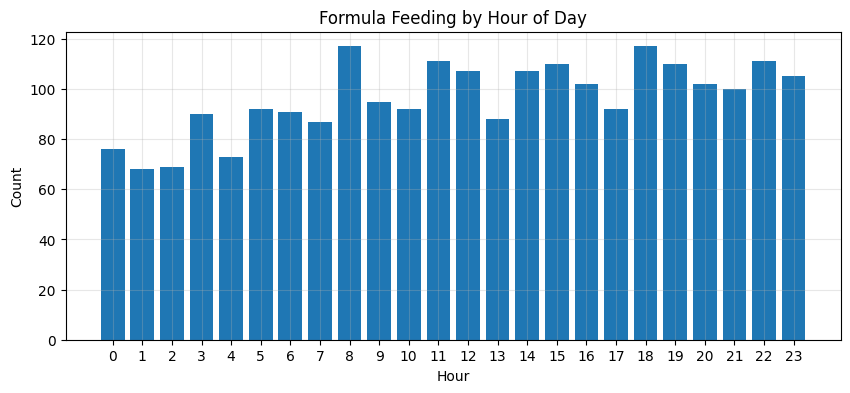

In [8]:
# Event frequency by hour
hourly = (
    df.with_columns(pl.col("time").str.slice(0, 2).cast(pl.Int32).alias("hour"))
    .group_by(["hour", "event"])
    .len()
    .sort(["hour", "event"])
)

# Formula by hour
formula_hourly = hourly.filter(pl.col("event") == "formula")

plt.figure(figsize=(10, 4))
plt.bar(formula_hourly["hour"], formula_hourly["len"])
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Formula Feeding by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()